In [18]:
# Cell 1: Import Libraries and Load Data
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load the dataset
df = pd.read_csv('attrition_balanced.csv')
# Label encode all object-type columns
df = df.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtypes == 'object' else col)

# Drop redundant ID-like columns
df.drop(['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1, inplace=True)

# Features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Min-Max Scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,2,1102,2,1,2,1,2,0,94,...,1,0,8,0,1,6,4,0,5,1
1,49,1,279,1,8,1,1,3,1,61,...,4,1,10,3,3,10,7,1,7,0
2,37,2,1373,1,2,2,4,4,1,92,...,2,0,7,3,3,0,0,0,0,1
3,33,1,1392,1,3,4,1,4,0,56,...,3,0,8,3,3,8,7,3,0,0
4,27,2,591,1,2,1,3,1,1,40,...,4,1,6,3,3,2,2,2,2,0


In [19]:
# Cell 2: Define Evaluation Function
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        from sklearn.calibration import CalibratedClassifierCV
        model = CalibratedClassifierCV(model, cv="prefit")
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

In [20]:
# Cell 3: Train SVM with Hyperparameter Tuning
from sklearn.svm import SVC

options = [
    {'C': 0.1, 'kernel': 'linear'},
    {'C': 1, 'kernel': 'rbf'},
    {'C': 10, 'kernel': 'rbf'},
    {'C': 100, 'kernel': 'rbf'}
]

for params in options:
    model = SVC(**params, gamma='scale', probability=True)
    model.fit(X_train, y_train)
    print(f"\nParams: {params}")
    print(evaluate_model(f"SVM {params}", model, X_test, y_test))


Params: {'C': 0.1, 'kernel': 'linear'}
{'Model': "SVM {'C': 0.1, 'kernel': 'linear'}", 'Accuracy': 0.8076923076923077, 'Precision': 0.8166666666666667, 'Recall': 0.7935222672064778, 'AUC': np.float64(0.8824517694110705)}

Params: {'C': 1, 'kernel': 'rbf'}
{'Model': "SVM {'C': 1, 'kernel': 'rbf'}", 'Accuracy': 0.868421052631579, 'Precision': 0.8760330578512396, 'Recall': 0.8582995951417004, 'AUC': np.float64(0.9392876460850039)}

Params: {'C': 10, 'kernel': 'rbf'}
{'Model': "SVM {'C': 10, 'kernel': 'rbf'}", 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.9587110098510055)}

Params: {'C': 100, 'kernel': 'rbf'}
{'Model': "SVM {'C': 100, 'kernel': 'rbf'}", 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.9602271795964529)}


In [44]:
# Cell 3: Train SVM with Hyperparameter Tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_params = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
svm = SVC(probability=True)
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
svm_results = evaluate_model("SVM", best_svm, X_test, y_test)
print("SVM Best Params:", svm_grid.best_params_)
print(svm_results)

SVM Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
{'Model': 'SVM', 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.958702814338868)}


In [23]:
# Cell 4: Train Decision Tree with Hyperparameter Tuning
from sklearn.tree import DecisionTreeClassifier

dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
dt_results = evaluate_model("Decision Tree", best_dt, X_test, y_test)
print("Decision Tree Best Params:", dt_grid.best_params_)
print(dt_results)

Decision Tree Best Params: {'max_depth': 10, 'min_samples_split': 10}
{'Model': 'Decision Tree', 'Accuracy': 0.8016194331983806, 'Precision': 0.7689530685920578, 'Recall': 0.8623481781376519, 'AUC': np.float64(0.815084659640381)}


In [24]:
# Cell 5: Train Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
bb_model = nb.fit(X_train, y_train)
nb_results = evaluate_model("Naive Bayes", nb, X_test, y_test)
print(nb_results)

{'Model': 'Naive Bayes', 'Accuracy': 0.6781376518218624, 'Precision': 0.6538461538461539, 'Recall': 0.757085020242915, 'AUC': np.float64(0.7878837548558408)}


In [46]:
# Cell 6: Logistic Regression with Forward and Backward Selection
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = LogisticRegression(max_iter=1000)

# Forward Selection
forward_selector = SequentialFeatureSelector(logreg, direction='forward', cv=5)
forward_selector.fit(X_train, y_train)
X_train_fwd = forward_selector.transform(X_train)
X_test_fwd = forward_selector.transform(X_test)
logreg_fwd = logreg.fit(X_train_fwd, y_train)
logreg_fwd_results = evaluate_model("LogReg Forward", logreg_fwd, X_test_fwd, y_test)

# Backward Selection
backward_selector = SequentialFeatureSelector(logreg, direction='backward', cv=5)
backward_selector.fit(X_train, y_train)
X_train_bwd = backward_selector.transform(X_train)
X_test_bwd = backward_selector.transform(X_test)
logreg_bwd = logreg.fit(X_train_bwd, y_train)
logreg_bwd_results = evaluate_model("LogReg Backward", logreg_bwd, X_test_bwd, y_test)

if (logreg_fwd_results['Accuracy'] > logreg_bwd_results['Accuracy']):
    logreg_results = logreg_fwd_results
else:
    logreg_results = logreg_bwd_results

print("Logistic Regression (Forward):", logreg_fwd_results)
print("Logistic Regression (Backward):", logreg_bwd_results)
print("Logistic Regression (Best):", logreg_results)

Logistic Regression (Forward): {'Model': 'LogReg Forward', 'Accuracy': 0.7975708502024291, 'Precision': 0.7951807228915663, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8683145109737908)}
Logistic Regression (Backward): {'Model': 'LogReg Backward', 'Accuracy': 0.805668016194332, 'Precision': 0.8081632653061225, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8822304905833566)}
Logistic Regression (Best): {'Model': 'LogReg Backward', 'Accuracy': 0.805668016194332, 'Precision': 0.8081632653061225, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8822304905833566)}


In [26]:
# Cell 7: Neural Network (MLP) with Hyperparameter Tuning
from sklearn.neural_network import MLPClassifier

mlp_params = {'hidden_layer_sizes': [(30,), (50,), (30, 30)], 'alpha': [0.0001, 0.01], 'max_iter': [300]}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=5, scoring='accuracy')
mlp_grid.fit(X_train, y_train)

best_mlp = mlp_grid.best_estimator_
mlp_results = evaluate_model("Neural Network", best_mlp, X_test, y_test)
print("MLP Best Params:", mlp_grid.best_params_)
print(mlp_results)

MLP Best Params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 300}
{'Model': 'Neural Network', 'Accuracy': 0.8582995951417004, 'Precision': 0.8416988416988417, 'Recall': 0.8825910931174089, 'AUC': np.float64(0.9408775754396893)}


In [27]:
# Cell 8: Random Forest with Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier

rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_results = evaluate_model("Random Forest", best_rf, X_test, y_test)
print("RF Best Params:", rf_grid.best_params_)
print(rf_results)

RF Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
{'Model': 'Random Forest', 'Accuracy': 0.888663967611336, 'Precision': 0.8934426229508197, 'Recall': 0.8825910931174089, 'AUC': np.float64(0.9606369552033306)}


In [28]:
# Cell 9: XGBoost with Hyperparameter Tuning
from xgboost import XGBClassifier

xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_results = evaluate_model("XGBoost", best_xgb, X_test, y_test)
print("XGBoost Best Params:", xgb_grid.best_params_)
print(xgb_results)

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
{'Model': 'XGBoost', 'Accuracy': 0.9008097165991903, 'Precision': 0.8928571428571429, 'Recall': 0.9109311740890689, 'AUC': np.float64(0.969512694848301)}


In [29]:
# Cell 10: K-Nearest Neighbors with Hyperparameter Tuning
from sklearn.neighbors import KNeighborsClassifier

knn_params = {'n_neighbors': [3, 5, 7, 9]}
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_
knn_results = evaluate_model("KNN", best_knn, X_test, y_test)
print("KNN Best Params:", knn_grid.best_params_)
print(knn_results)

KNN Best Params: {'n_neighbors': 3}
{'Model': 'KNN', 'Accuracy': 0.8036437246963563, 'Precision': 0.7329192546583851, 'Recall': 0.9554655870445344, 'AUC': np.float64(0.8904997623301479)}


In [30]:
# Cell 11: K-Means Clustering + Evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

# Evaluate using silhouette and dummy classifier eval format
kmeans_pred = kmeans.predict(X_test)
kmeans_results = {
    "Model": "K-Means",
    "Accuracy": accuracy_score(y_test, kmeans_pred),
    "Precision": precision_score(y_test, kmeans_pred),
    "Recall": recall_score(y_test, kmeans_pred),
    "AUC": roc_auc_score(y_test, kmeans_pred)
}
print(kmeans_results)

{'Model': 'K-Means', 'Accuracy': 0.4109311740890688, 'Precision': 0.412, 'Recall': 0.41700404858299595, 'AUC': np.float64(0.4109311740890689)}


In [31]:
# Cell 12: Hierarchical Clustering + Evaluation
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
agg_pred = agg.fit_predict(X_test)
agg_results = {
    "Model": "Hierarchical Clustering",
    "Accuracy": accuracy_score(y_test, agg_pred),
    "Precision": precision_score(y_test, agg_pred),
    "Recall": recall_score(y_test, agg_pred),
    "AUC": roc_auc_score(y_test, agg_pred)
}
print(agg_results)

{'Model': 'Hierarchical Clustering', 'Accuracy': 0.3623481781376518, 'Precision': 0.35714285714285715, 'Recall': 0.3441295546558704, 'AUC': np.float64(0.36234817813765186)}


In [32]:
# Cell 13: Ensemble Method #1 (Voting Classifier with SVM, DT, NN)
from sklearn.ensemble import VotingClassifier

ensemble1 = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft')
ensemble1.fit(X_train, y_train)
ensemble1_results = evaluate_model("Ensemble #1 (SVM+DT+NN)", ensemble1, X_test, y_test)
print(ensemble1_results)

{'Model': 'Ensemble #1 (SVM+DT+NN)', 'Accuracy': 0.8825910931174089, 'Precision': 0.8735177865612648, 'Recall': 0.8947368421052632, 'AUC': np.float64(0.9539412217869494)}


In [33]:
# Cell 14: Ensemble Method #2 (Bagging with Decision Trees)
from sklearn.ensemble import BaggingClassifier

ensemble2 = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)
ensemble2.fit(X_train, y_train)
ensemble2_results = evaluate_model("Ensemble #2 (Bagged DT)", ensemble2, X_test, y_test)
print(ensemble2_results)

{'Model': 'Ensemble #2 (Bagged DT)', 'Accuracy': 0.8623481781376519, 'Precision': 0.8594377510040161, 'Recall': 0.8663967611336032, 'AUC': np.float64(0.934001540756282)}


In [34]:
# Cell 15: Final Summary Table
summary_df = pd.DataFrame([
    svm_results, dt_results, nb_results,
    logreg_fwd_results, logreg_bwd_results, mlp_results,
    rf_results, xgb_results, knn_results,
    kmeans_results, agg_results,
    ensemble1_results, ensemble2_results
])

summary_df = summary_df[['Model', 'Accuracy', 'AUC']]
print("\nModel Summary (Accuracy & AUC):")
print(summary_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


Model Summary (Accuracy & AUC):
                      Model  Accuracy       AUC
0                   XGBoost  0.900810  0.969513
1                       SVM  0.896761  0.958727
2             Random Forest  0.888664  0.960637
3   Ensemble #1 (SVM+DT+NN)  0.882591  0.953941
4   Ensemble #2 (Bagged DT)  0.862348  0.934002
5            Neural Network  0.858300  0.940878
6           LogReg Backward  0.805668  0.882230
7                       KNN  0.803644  0.890500
8             Decision Tree  0.801619  0.815085
9            LogReg Forward  0.797571  0.868315
10              Naive Bayes  0.678138  0.787884
11                  K-Means  0.410931  0.410931
12  Hierarchical Clustering  0.362348  0.362348


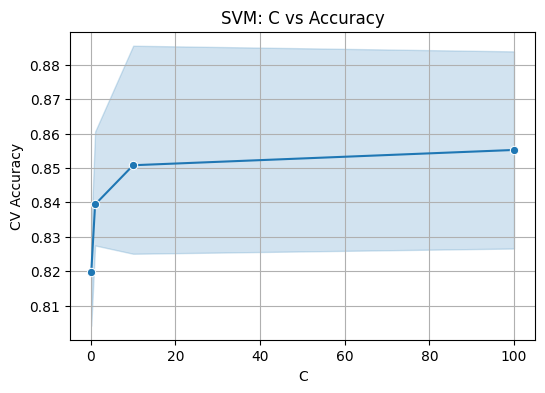

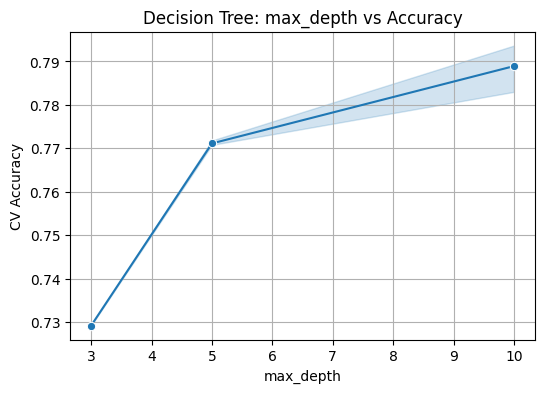

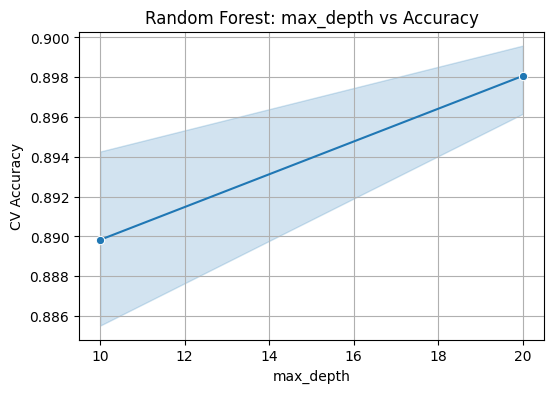

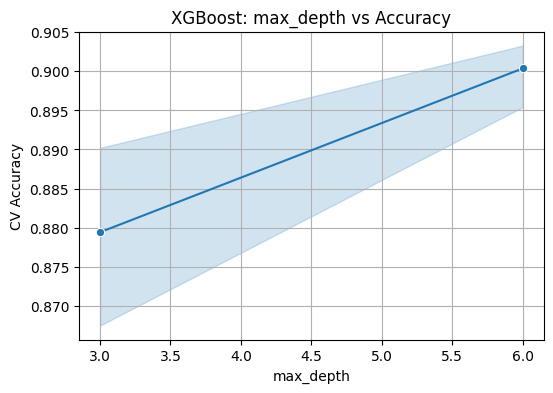

In [45]:
# Cell 16: Plot Hyperparameter vs Accuracy Graphs
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grid_scores(grid, param_name, model_name):
    results = pd.DataFrame(grid.cv_results_)
    scores = results[['params', 'mean_test_score']]
    scores[param_name] = scores['params'].apply(lambda x: x[param_name])
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=scores[param_name], y=scores['mean_test_score'], marker='o')
    plt.title(f"{model_name}: {param_name} vs Accuracy")
    plt.xlabel(param_name)
    plt.ylabel("CV Accuracy")
    plt.grid(True)
    plt.show()

# Example usage (you can uncomment one at a time to view plots):
plot_grid_scores(svm_grid, 'C', 'SVM')
plot_grid_scores(dt_grid, 'max_depth', 'Decision Tree')
plot_grid_scores(rf_grid, 'max_depth', 'Random Forest')
plot_grid_scores(xgb_grid, 'max_depth', 'XGBoost')
#plot_grid_scores(mlp_grid, 'hidden_layer_sizes', 'MLP Neural Net')